In [1]:
import pandas as pd
import numpy as np
from utils.demeaning import demean_2FE
from sklearn.model_selection import GroupKFold
from collections import Counter
from linearmodels.panel import PanelOLS
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
import matplotlib.pyplot as plt

In [2]:
# Loading data
df_crop = pd.read_parquet("../data/processed/crop_annual.parquet")
df_weather = pd.read_parquet("../data/processed/weather_state_month.parquet")

# Checking dtypes for merge
print(df_crop.dtypes, '\n')
print(df_weather.dtypes)

state_alpha       object
year               int64
crop              object
yield             object
area_harvested    object
dtype: object 

state          object
year            int64
month           int64
avg_temp      float64
prcp          float64
n_stations      int64
temp_Z        float64
prcp_Z        float64
dtype: object


In [3]:
# Checking for missing values
print(df_crop.isna().sum(), '\n')
print(df_weather.isna().sum(), '\n')

# Listwise deletion of empty values
df_weather.dropna(inplace=True)

# Comparing year ranges
print(df_weather['year'].max(), df_weather['year'].min())
print(df_crop['year'].max(), df_crop['year'].min())

state_alpha       0
year              0
crop              0
yield             0
area_harvested    0
dtype: int64 

state          0
year           0
month          0
avg_temp      35
prcp           8
n_stations     0
temp_Z        35
prcp_Z         8
dtype: int64 

2026 1884
2025 1961


In [4]:
df_weather.columns

Index(['state', 'year', 'month', 'avg_temp', 'prcp', 'n_stations', 'temp_Z',
       'prcp_Z'],
      dtype='object')

In [5]:
# Restricting weather df year range
df_weather = df_weather[df_weather["year"].between(1961, 2025)]

# Analysis

First stage target: log yield


Second stage target: log area harvested in t+1

In [6]:
w = df_weather.copy()

# Building wide tables of monthly instruments
tempZ = w.pivot_table(index=["state","year"], columns="month", values="temp_Z", aggfunc="mean")
prcpZ = w.pivot_table(index=["state","year"], columns="month", values="prcp_Z", aggfunc="mean")

# Giving names to columns based on month with prefix Z_
tempZ.columns = [f"Z_temp_m{int(m)}" for m in tempZ.columns]
prcpZ.columns = [f"Z_prcp_m{int(m)}" for m in prcpZ.columns]

Zwide = tempZ.join(prcpZ).reset_index()

# Merging weather with IVs on crop
df_Z = df_crop.merge(
    Zwide,
    left_on=["state_alpha","year"],
    right_on=["state","year"],
    how="inner"
).copy()

In [7]:
# Need to strip commas from area harvested
df_Z["area_harvested"] = df_Z["area_harvested"].astype(str).str.replace(",", "")

# Turning to numeric
df_Z['area_harvested'] = pd.to_numeric(df_Z['area_harvested'], errors='coerce')

# Taking logarithm of area harvested
df_Z["log_area"] = np.log(df_Z["area_harvested"])

# Renaming yield to crop and creating log transformed yield
df_Z.rename(columns={"yield": 'crop_yield'}, inplace=True)
df_Z["crop_yield"] = pd.to_numeric(df_Z["crop_yield"], errors="coerce")
df_Z["log_yield"] = np.log(df_Z["crop_yield"].clip(lower=1e-6))

# Concatenating state ids to crop ids e.g. TX_Wheat
df_Z["entity_id"] = df_Z["state_alpha"].astype(str) + "_" + df_Z["crop"].astype(str)

# Instrument columns
X = [c for c in df_Z.columns if c.startswith("Z_")]

# Creating panel df
df_Z = df_Z.dropna(subset=["entity_id","year","log_yield"] + X).copy()
dfp = df_Z.set_index(["entity_id","year"]).sort_index()

# Creating 2SLS outcome - future log area
dfp["log_area_lead1"] = (
    dfp.groupby(level="entity_id")["log_area"]
       .shift(-1)
)

# Wide IV Matrix

In [8]:
y = "log_yield"
X = [c for c in dfp.columns if c.startswith("Z_")]

exog = dfp[X]
mod = PanelOLS(dfp[y], exog, entity_effects=True, time_effects=True)

res = mod.fit(cov_type="clustered", cluster_entity=True)
print(res.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              log_yield   R-squared:                        0.0717
Estimator:                   PanelOLS   R-squared (Between):             -0.0022
No. Observations:                2673   R-squared (Within):              -0.0829
Date:                Mon, Jan 26 2026   R-squared (Overall):             -0.0026
Time:                        14:09:12   Log-likelihood                    1273.6
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      8.1849
Entities:                          42   P-value                           0.0000
Avg Obs:                       63.643   Distribution:                 F(24,2543)
Min Obs:                       51.000                                           
Max Obs:                       65.000   F-statistic (robust):             34.708
                            

# Interpretation
0.202 R - > some signal
Joint significance F=4.6 (0.00) significant

Overall R^2 close to 0, FEs doing all of the work. All explanatory power comes from FEs.

No explosive SEs. Meaningful coeffs.

Around 2% of within–state/crop variation in planted area is explained.

# LASSO Selection

In [9]:
y = "log_yield"
Z = [c for c in dfp.columns if c.startswith("Z_")]

# Taking outcome and IVs and two-way demeaning
df_dm = demean_2FE(dfp[[y] + Z].dropna())

# Splitting demeaned outcome and regressors
y_dm = df_dm[y].values
X_dm = df_dm[Z].values

# Standardising X with scaler
X_std = StandardScaler().fit_transform(X_dm)


groups = df_dm.index.get_level_values("entity_id")
gkf = GroupKFold(n_splits=5)

# Choosing lasso coeff with KFold
lasso = LassoCV(
    cv=gkf.split(X_std, y_dm, groups=groups),
    fit_intercept=False,
    max_iter=20000,
    n_jobs=-1
).fit(X_std, y_dm)

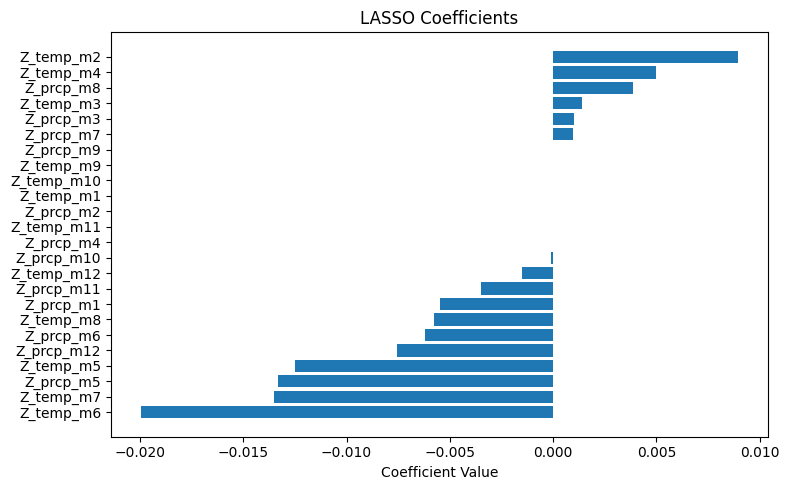

In [10]:
# Taking coefficients
coef = lasso.coef_
coef_df = pd.DataFrame({
    "variable": Z,
    "coef": coef
})

# Sorting values
coef_df = coef_df.sort_values("coef")

# Plotting
plt.figure(figsize=(8, 5))
plt.barh(coef_df["variable"], coef_df["coef"])
plt.title("LASSO Coefficients")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()


In [11]:
# Extracting non-zero coefficients
selected = np.array(Z)[lasso.coef_ != 0]

print(f"Selected {len(selected)} variables:")
print(selected)

Selected 17 variables:
['Z_temp_m2' 'Z_temp_m3' 'Z_temp_m4' 'Z_temp_m5' 'Z_temp_m6' 'Z_temp_m7'
 'Z_temp_m8' 'Z_temp_m12' 'Z_prcp_m1' 'Z_prcp_m3' 'Z_prcp_m5' 'Z_prcp_m6'
 'Z_prcp_m7' 'Z_prcp_m8' 'Z_prcp_m10' 'Z_prcp_m11' 'Z_prcp_m12']


We next try to estimate robust predictors using **stability selection across subsamples.**

The main idea is that a variable that is important to the model will be chosen consistently across subsamples

In [12]:
y = "log_yield"
Z = [c for c in dfp.columns if c.startswith("Z_")]
years = dfp.index.get_level_values("year").unique()

selection_counts = Counter()
n_runs = 50
n_drop_years = 5

for _ in range(n_runs):
    drop_years = np.random.choice(years, size=n_drop_years, replace=False)
    df_sub = dfp.loc[~dfp.index.get_level_values("year").isin(drop_years)]

    df_dm = demean_2FE(df_sub[[y] + Z].dropna())
    y_dm = df_dm[y].values
    X_dm = df_dm[Z].values

    X_std = StandardScaler().fit_transform(X_dm)

    # Grouping by entity
    groups = df_dm.index.get_level_values("entity_id")
    gkf = GroupKFold(n_splits=5)

    lasso = LassoCV(
        cv=gkf.split(X_std, y_dm, groups=groups),
        fit_intercept=False,
        max_iter=10000,
        n_jobs=-1
    ).fit(X_std, y_dm)

    selected = np.array(Z)[lasso.coef_ != 0]
    selection_counts.update(selected)

freq = {k: v / n_runs for k, v in selection_counts.items()}
freq_sorted = dict(sorted(freq.items(), key=lambda x: -x[1]))


In [13]:
# Dropping weaker instruments (chosen >0.8 of the time)
THRESH = 0.8
filtered_vars = [k for k, v in freq_sorted.items() if v >= THRESH]
print(f"We chose {len(filtered_vars)} variables")
print('Precipitation:')
print(f'{[str(v) for v in filtered_vars if 'prcp' in v]}')
print('Temperature:')
print(f'{[str(v) for v in filtered_vars if 'temp' in v]}')


We chose 13 variables
Precipitation:
['Z_prcp_m1', 'Z_prcp_m5', 'Z_prcp_m6', 'Z_prcp_m8', 'Z_prcp_m11', 'Z_prcp_m12']
Temperature:
['Z_temp_m2', 'Z_temp_m4', 'Z_temp_m5', 'Z_temp_m6', 'Z_temp_m7', 'Z_temp_m8', 'Z_temp_m3']


In [14]:
# Selecting new Z vector
Z_selected = [str(v) for v in filtered_vars]

# Re-running FE regression
df_final = dfp[[y] + Z_selected].dropna()

model = PanelOLS(
    df_final[y],
    df_final[Z_selected],
    entity_effects=True,
    time_effects=True
)

res_final = model.fit(
    cov_type="clustered",
    cluster_entity=True
)

print(res_final.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              log_yield   R-squared:                        0.0696
Estimator:                   PanelOLS   R-squared (Between):             -0.0023
No. Observations:                2673   R-squared (Within):              -0.0678
Date:                Mon, Jan 26 2026   R-squared (Overall):             -0.0026
Time:                        14:09:20   Log-likelihood                    1270.6
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      14.708
Entities:                          42   P-value                           0.0000
Avg Obs:                       63.643   Distribution:                 F(13,2554)
Min Obs:                       51.000                                           
Max Obs:                       65.000   F-statistic (robust):             26.247
                            

# Interpretation
We have joint significance. Slightly lower R^2, expected. Coefficients look good. FE still doing most of work

# Saving Data for Non-Linear Model Exploration

In [15]:
import json
from pathlib import Path

OUT = Path("../data/processed")
OUT.mkdir(exist_ok=True)

y_endog = 'log_yield'
Z_sel = [str(v) for v in Z_selected]

# Saving metadata from LASSO selection
final = {
    "endog": y_endog,
    "entity_level": 'entity_id',
    "time_level": "year",
    "Z_selected": Z_sel,
}

with open(OUT / "final.json", "w") as f:
    json.dump(final, f, indent=2)

# Saving BFS selection data set
df_bfs = (
    dfp[['log_area_lead1',y_endog] + Z_selected]
    .dropna()
    .reset_index()
)

df_bfs.to_parquet(OUT / "bfs_data.parquet", index=False)